# Held-out NL→FOL Faithfulness Meta-Evaluation Set — `data.py` demo

This dataset is for **meta-evaluating metrics of NL→FOL (autoformalization) output quality**. Each row pairs a
natural-language sentence with a *candidate* first-order-logic formalization produced by a real system. The label
(`output`) says whether the formula is **faithful** to the sentence: `faithful` / `unfaithful` / `unknown`
(`unlabeled` for the transfer group).

The full artifact has 15,606 rows in 5 groups:

| group | what it holds |
|---|---|
| `heldout_confirm` | 6,300 greedy candidates: 700 sentences (MALLS-v0.1-test, FOLIO-v2-train, ProverQA-dev) × 9 OpenRouter systems. Unparseable outputs are kept. |
| `heldout_samples` | 7,000 samples at T=0.8 from gpt-4.1-mini and llama-3.1-8b |
| `screen_gold_audit` | 1,003 Logic-LM FOLIO-dev candidates, labelled against audited gold |
| `contamination` | 936 entity-renamed paraphrase rows, used to test whether LLM judges benefit from having seen the public gold |
| `transfer_unlabeled` | 367 of the user's EU-AI-Act pilot formulas |

Labels come from layers of evidence. **L0**: a panel of three models from different families audits the gold
formula. **L1**: z3 checks logical equivalence up to renaming of predicates. **L2**: WordNet definitions handle
differences in granularity. **L3**: three models judge blinded A/B pairs. Each row records the lineage of every layer.

**What `data.py` does (and what this notebook runs):** it is the *final* step of the pipeline. It reads the
assembled, labelled rows (`work/assembled_data_out.json.gz`) and checks **every row against the original
public source datasets**. The sentence and gold formula must match the MALLS, FOLIO, or ProverQA record the row
names. Logic-LM lines must appear in the Logic-LM output files. Contamination rows must derive from a held-out
sentence. Pilot formulas must match the pilot files. The script records `metadata_source_verified` and
`metadata_source_file` on each row, never drops a row, and writes `full_data_out.json`.

This demo runs the **original code unchanged** on a 100-row curated subset (20 per group). `mini_demo_data.json`
includes the exact source-dataset records those rows need to be verified.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- original import block of data.py (unchanged) ---
from __future__ import annotations

import ast
import gzip
import json
import re
import sys
from collections import Counter
from pathlib import Path

from loguru import logger

# --- extra imports for the notebook (data loading + visualisation) ---
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-abf543-do-sentence-and-formula-generalize-the/main/round-1/dataset-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print({d["dataset"]: len(d["examples"]) for d in data["assembled"]["datasets"]}, "| source files:", len(data["source_files"]))

Mini demo subset of the Held-out NL-to-FOL Faithfulness Meta-Evaluation Set: 100 candidate formalizations (20 per group) in the pre-verification form data.py reads (work/assembled_data_out.json.gz), plus the exact source-dataset records data.py needs to re-verify them (MALLS-v0.1-test, DSAVlab curated MALLS, FOLIO v2 train, ProverQA dev, FOLIO v0.0 validation + Logic-LM outputs, user DPV pilot formulas).
{'heldout_confirm': 20, 'heldout_samples': 20, 'screen_gold_audit': 20, 'contamination': 20, 'transfer_unlabeled': 20} | source files: 29


## Configuration

`data.py` has only one "size" knob: how many rows it processes. The original run processes **every row** of
every group (6,300 / 7,000 / 1,003 / 936 / 367 = 15,606). The demo file holds 20 rows per group. `N_PER_GROUP`
sets how many of them go through the pipeline.

The demo rows are ordered so that any prefix still verifies. Contamination rows `2i` and `2i+1` come from the
held-out sentence at `heldout_confirm` row `2i`.

In [5]:
N_PER_GROUP = 20   # rows per group taken from the demo file (max 20 in mini_demo_data.json)
# Original: all rows of the full dataset — N_PER_GROUP = None  (6300 + 7000 + 1003 + 936 + 367 = 15,606 rows)

## Setup (from `data.py`)

These are paths, logging, the fixed order of the five groups, and the keys a row must never contain.
The only change is `ROOT`: the original script uses its own directory (`Path(__file__).resolve().parent`),
which a notebook doesn't have, so the notebook uses the current working directory.

In [6]:
ROOT = Path.cwd()  # original: Path(__file__).resolve().parent
TD = ROOT / "temp" / "datasets"
(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "data_py.log", rotation="30 MB", level="DEBUG")

GROUP_ORDER = ["heldout_confirm", "heldout_samples", "screen_gold_audit", "contamination", "transfer_unlabeled"]
FORBIDDEN = {"split", "dataset", "context"}

## Materialise the demo inputs at the paths `data.py` expects

This cell is **not** part of `data.py`. It lets the original code run without any edits:

* the first `N_PER_GROUP` rows of each group go to `work/assembled_data_out.json.gz`, the pipeline output that `main()` reads;
* each source-file excerpt goes to its original relative path under `temp/datasets/`. Examples:
  `yuan-yang__MALLS-v0/MALLS-v0.1-test.json`, `tasksource__folio/folio_v2_train.jsonl`,
  `opendatalab__ProverQA/dev/hard.json`, the FOLIO v0.0 validation file and the Logic-LM outputs, and the pilot `04_fol.json` files.
  The excerpts hold only the records the demo rows point to. The MALLS list keeps each record at its original
  index, with `null` in the other positions, so the index-based lookup `src["malls"][i]` still works.

In [7]:
_assembled = {"metadata": data["assembled"]["metadata"],
              "datasets": [{"dataset": d["dataset"], "examples": d["examples"][:N_PER_GROUP]}
                           for d in data["assembled"]["datasets"]]}
(ROOT / "work").mkdir(exist_ok=True)
with gzip.open(ROOT / "work" / "assembled_data_out.json.gz", "wt", encoding="utf-8") as fh:
    json.dump(_assembled, fh, ensure_ascii=False)
for rel, content in data["source_files"].items():
    p = TD / rel
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text(content, encoding="utf-8")
print("rows per group:", {d["dataset"]: len(d["examples"]) for d in _assembled["datasets"]})
print("source files written under", TD, ":", len(data["source_files"]))

rows per group: {'heldout_confirm': 20, 'heldout_samples': 20, 'screen_gold_audit': 20, 'contamination': 20, 'transfer_unlabeled': 20}
source files written under /ai-inventor/aii_data/runs/run_ujABDGgoK_5Q/4_gen_paper_repo/_4_gen_demo_art/notebook_workspaces/iter_1/art_iyzYyaqlqpSX/test_run/temp/datasets : 29


## Text-normalisation helpers

`norm` lower-cases the text, collapses whitespace and removes a trailing period, so sentences can be matched
against FOLIO v0.0 (which formats them slightly differently). `ws` only collapses whitespace and is used for
exact formula comparison. `read_jsonl` reads JSON-lines files.

In [8]:
def norm(s: str) -> str:
    s = re.sub(r"\s+", " ", s.strip().lower())
    return s[:-1].strip() if s.endswith(".") else s


def ws(s: str) -> str:
    return re.sub(r"\s+", " ", (s or "").strip())


def read_jsonl(p: Path) -> list[dict]:
    return [json.loads(l) for l in p.read_text(encoding="utf-8").splitlines() if l.strip()]

## Load the public source datasets

`load_sources` builds lookup tables:

* `malls` is the MALLS-v0.1-test list, indexed by position. `malls_cur` holds the DSAVlab-UNIUD human-corrected
  MALLS gold, keyed by 0-based id.
* `folio_train` holds FOLIO v2 train, keyed by `example_id`. `proverqa` maps `(level, id)` to the list of
  (NL, FOL) pairs from `nl2fol`.
* `folio_v1_val` maps each normalised FOLIO v0.0 validation sentence (premise or conclusion) to its set of
  gold FOL strings.
* `logiclm` holds, for each Logic-LM system, the set of program lines that contain `:::`, the separator between FOL and NL in Logic-LM output.

In [9]:
def load_sources() -> dict:
    src = {}
    src["malls"] = json.loads((TD / "yuan-yang__MALLS-v0" / "MALLS-v0.1-test.json").read_text())
    src["malls_cur"] = {c["id"] - 1: c for c in read_jsonl(TD / "DSAVlab-UNIUD__MALLS_test_subset-CURATED" / "MALLS_instances.jsonl")}
    src["folio_train"] = {str(r["example_id"]): r for r in read_jsonl(TD / "tasksource__folio" / "folio_v2_train.jsonl")}
    src["proverqa"] = {}
    for lvl in ("medium", "hard"):
        for it in json.loads((TD / "opendatalab__ProverQA" / "dev" / f"{lvl}.json").read_text()):
            d = it["nl2fol"]
            d = ast.literal_eval(d) if isinstance(d, str) else d
            src["proverqa"][(lvl, str(it["id"]))] = list(d.items())
    gh = TD / "github_FOLIO_v0.0_and_LogicLM_outputs"
    val = {}
    for s in read_jsonl(gh / "folio-validation_v0.0.jsonl"):
        p = s["premises"]
        p = ast.literal_eval(p) if isinstance(p, str) and p.startswith("[") else p
        pf = s["premises-FOL"]
        pf = ast.literal_eval(pf) if isinstance(pf, str) and pf.startswith("[") else pf
        for nl, f in list(zip(p, pf)) + [(s["conclusion"], s["conclusion-FOL"])]:
            val.setdefault(norm(nl), set()).add(ws(f))
    src["folio_v1_val"] = val
    src["logiclm"] = {}
    for sysname in ("gpt-3.5-turbo", "gpt-4", "text-davinci-003"):
        txt = "\n".join(ex["raw_logic_programs"][0] for ex in json.loads((gh / f"FOLIO_dev_{sysname}.json").read_text())
                        if ex.get("raw_logic_programs"))
        src["logiclm"][f"logiclm_{sysname}"] = {ws(l) for l in txt.split("\n") if ":::" in l}
    return src

## Per-group verifiers

Each verifier returns `(ok, source_file_description)`.

* **`verify_heldout`** (for `heldout_confirm` and `heldout_samples`) parses `metadata_source_id`
  (`malls_test_<i>`, `folio_train_story<S>_ex<E>_<p<j>|c>`, `proverqa_dev_<level>_<id>_<k>`). It fetches the named
  source record and requires the sentence **and** the original gold FOL to match up to whitespace. For MALLS rows
  that carry the paper-corrected gold, that gold must also match the DSAVlab curated record.
* **`verify_screen`** requires the gold to be one of the FOLIO v0.0 validation gold formulas for that sentence,
  and the candidate (`metadata_raw_output`) to be a real line from that system's Logic-LM output file.
* **`verify_transfer`** requires the candidate formula to match the `fol` field of the pilot `04_fol.json` it came from.

In [10]:
def verify_heldout(ex: dict, src: dict) -> tuple[bool, str]:
    inp = json.loads(ex["input"])
    sent, gold, sid = inp["sentence"], ex["metadata_gold_fol_original"], ex["metadata_source_id"]
    m = re.match(r"malls_test_(\d+)$", sid)
    if m:
        i = int(m.group(1))
        rec = src["malls"][i]
        ok = ws(rec["NL"]) == ws(sent) and ws(rec["FOL"]) == ws(gold)
        if ex.get("metadata_gold_fol_paper"):
            ok = ok and ws(src["malls_cur"][i]["FOL_sentence_new"]) == ws(ex["metadata_gold_fol_paper"])
        return ok, f"yuan-yang__MALLS-v0/MALLS-v0.1-test.json[{i}]"
    m = re.match(r"folio_train_story(\w+)_ex(\w+)_(p\d+|c)$", sid)
    if m:
        rec = src["folio_train"].get(m.group(2))
        if rec is None:
            return False, "tasksource__folio/folio_v2_train.jsonl (example missing)"
        pos = m.group(3)
        if pos == "c":
            nl, fol = rec["conclusion"], rec["conclusion-FOL"]
        else:
            j = int(pos[1:])
            nl = [l for l in rec["premises"].split("\n") if l.strip()][j]
            fol = [l for l in rec["premises-FOL"].split("\n") if l.strip()][j]
        return ws(nl) == ws(sent) and ws(fol) == ws(gold), f"tasksource__folio/folio_v2_train.jsonl[example_id={m.group(2)},{pos}]"
    m = re.match(r"proverqa_dev_(medium|hard)_(\w+)_(\d+)$", sid)
    if m:
        items = src["proverqa"].get((m.group(1), m.group(2)))
        if items is None:
            return False, "opendatalab__ProverQA (item missing)"
        nl, fol = items[int(m.group(3))]
        return ws(nl) == ws(sent) and ws(fol) == ws(gold), f"opendatalab__ProverQA/dev/{m.group(1)}.json[id={m.group(2)}][{m.group(3)}]"
    return False, "unknown source_id pattern"


def verify_screen(ex: dict, src: dict) -> tuple[bool, str]:
    inp = json.loads(ex["input"])
    golds = src["folio_v1_val"].get(norm(inp["sentence"]), set())
    ok_gold = ws(ex["metadata_gold_fol_original"]) in golds
    ok_line = ws(ex["metadata_raw_output"]) in src["logiclm"].get(ex["metadata_system"], set())
    return ok_gold and ok_line, f"github FOLIO v0.0 validation + Logic-LLM FOLIO_dev_{ex['metadata_system'].replace('logiclm_', '')}.json"


def verify_transfer(ex: dict) -> tuple[bool, str]:
    rel = ex["metadata_source_path"].replace("raw/pilot/", "", 1)
    p = TD / "user_dpv_pilot" / rel
    if not p.exists():
        return False, str(p.relative_to(ROOT))
    try:
        fol = json.loads(p.read_text()).get("fol", "")
    except json.JSONDecodeError:
        fol = p.read_text()
    return ws(fol) == ws(json.loads(ex["input"])["candidate_fol"]), f"temp/datasets/user_dpv_pilot/{rel}"

## `main()`: schema checks, source verification, and writing `full_data_out.json`

For every group, in `GROUP_ORDER`:
1. It asserts the `exp_sel_data_out` row contract: `input` and `output` are strings, no forbidden keys, and every
   other key starts with `metadata_`.
2. It runs the verifier for that group. Contamination rows must have an `original_sentence` equal to the
   held-out sentence with the same `metadata_sentence_id`.
3. It stores `metadata_source_verified` and `metadata_source_file` on the row. Rows are never dropped.
4. It counts verified rows and the label distribution for each group, adds these under `source_verification` in
   the metadata, and writes `full_data_out.json`.

In [11]:
@logger.catch(reraise=True)
def main() -> None:
    with gzip.open(ROOT / "work" / "assembled_data_out.json.gz", "rt", encoding="utf-8") as fh:
        data = json.load(fh)
    src = load_sources()
    logger.info(f"sources loaded: malls={len(src['malls'])} folio_train={len(src['folio_train'])} proverqa_items={len(src['proverqa'])}")
    groups = {d["dataset"]: d["examples"] for d in data["datasets"]}
    held_sent = {}
    for ex in groups.get("heldout_confirm", []):
        held_sent[ex["metadata_sentence_id"]] = json.loads(ex["input"])["sentence"]
    stats = {}
    out = []
    for g in GROUP_ORDER:
        rows = groups.get(g, [])
        c = Counter()
        for ex in rows:
            assert isinstance(ex["input"], str) and isinstance(ex["output"], str), ex.get("metadata_item_id")
            bad = FORBIDDEN & set(ex)
            assert not bad, bad
            assert all(k in ("input", "output") or k.startswith("metadata_") for k in ex), ex.keys()
            if g in ("heldout_confirm", "heldout_samples"):
                ok, f = verify_heldout(ex, src)
            elif g == "screen_gold_audit":
                ok, f = verify_screen(ex, src)
            elif g == "contamination":
                ok = held_sent.get(ex["metadata_sentence_id"]) == ex["metadata_original_sentence"]
                f = "derived from heldout_confirm sentence " + ex["metadata_sentence_id"]
            else:
                ok, f = verify_transfer(ex)
            ex["metadata_source_verified"] = bool(ok)
            ex["metadata_source_file"] = f
            c[ok] += 1
        stats[g] = {"rows": len(rows), "source_verified": c[True], "not_verified": c[False],
                    "labels": dict(Counter(ex["output"] for ex in rows))}
        logger.info(f"{g}: {stats[g]}")
        out.append({"dataset": g, "examples": rows})
    meta = dict(data["metadata"])
    meta["source_verification"] = stats
    meta["groups"] = GROUP_ORDER
    (ROOT / "full_data_out.json").write_text(json.dumps({"metadata": meta, "datasets": out}, ensure_ascii=False))
    logger.info(f"wrote full_data_out.json: {sum(len(d['examples']) for d in out)} examples in {len(out)} datasets")

## Run it

In [12]:
if __name__ == "__main__":
    main()

07:13:17|INFO   |sources loaded: malls=763 folio_train=9 proverqa_items=5


07:13:17|INFO   |heldout_confirm: {'rows': 20, 'source_verified': 20, 'not_verified': 0, 'labels': {'faithful': 6, 'unfaithful': 11, 'unknown': 3}}


07:13:17|INFO   |heldout_samples: {'rows': 20, 'source_verified': 20, 'not_verified': 0, 'labels': {'unknown': 7, 'faithful': 7, 'unfaithful': 6}}


07:13:17|INFO   |screen_gold_audit: {'rows': 20, 'source_verified': 20, 'not_verified': 0, 'labels': {'faithful': 7, 'unfaithful': 7, 'unknown': 6}}


07:13:17|INFO   |contamination: {'rows': 20, 'source_verified': 20, 'not_verified': 0, 'labels': {'faithful': 6, 'unfaithful': 14}}


07:13:17|INFO   |transfer_unlabeled: {'rows': 20, 'source_verified': 20, 'not_verified': 0, 'labels': {'unlabeled': 20}}


07:13:17|INFO   |wrote full_data_out.json: 100 examples in 5 datasets


## Results

This section reads back the `full_data_out.json` that `main()` just wrote and summarises it:

* how many rows were verified against the source datasets, and the label distribution for each group;
* a few example rows, each showing the sentence, the candidate, the original gold, the audited gold, how the label was derived, and the label;
* the label mix by group, and, for `heldout_confirm`, the faithfulness labels by complexity tercile. The
  full dataset has more wrong gold in long, heavily conditioned sentences.

The numbers here describe only the 100-row demo subset, which was curated for diversity rather than randomly
sampled, so they are **not** estimates for the full dataset. The full-dataset rates are in the artifact's
`label_report.json`. For example, 43.9% [39.5, 48.6] of candidates the solver found non-equivalent are faithful
according to the panel.

=== Source verification + labels per group ===


             group  rows  source_verified  not_verified  label=faithful  label=unfaithful  label=unknown  label=unlabeled
   heldout_confirm    20               20             0             6.0              11.0            3.0              0.0
   heldout_samples    20               20             0             7.0               6.0            7.0              0.0
 screen_gold_audit    20               20             0             7.0               7.0            6.0              0.0
     contamination    20               20             0             6.0              14.0            0.0              0.0
transfer_unlabeled    20               20             0             0.0               0.0            0.0             20.0

=== Example held-out rows (sentence, candidate, original gold, audited gold, label lineage) ===
----------------------------------------------------------------------------------------------------
             metadata_system: deepseek-v3.1
                    senten

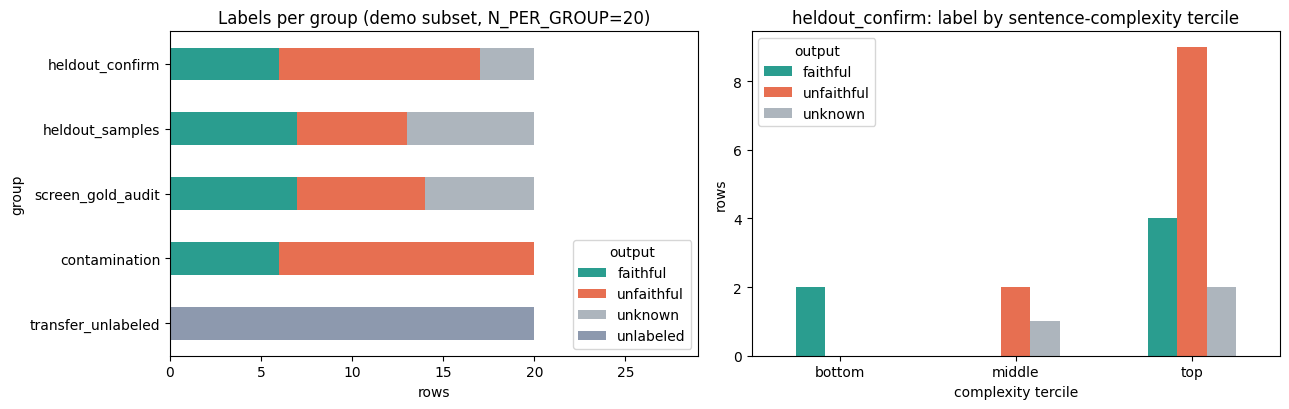


heldout_confirm label source (L0-L3 lineage):
metadata_label_source
equiv_audited_gold      11
panel3                   5
unknown                  3
equiv_synthetic_gold     1

All 100 rows source-verified: True


In [13]:
res = json.loads((ROOT / "full_data_out.json").read_text())
sv = res["metadata"]["source_verification"]
summary = pd.DataFrame([{"group": g, "rows": s["rows"], "source_verified": s["source_verified"],
                         "not_verified": s["not_verified"], **{f"label={k}": v for k, v in s["labels"].items()}}
                        for g, s in sv.items()]).fillna(0)
print("=== Source verification + labels per group ===")
print(summary.to_string(index=False))

rows = [dict(ex, group=d["dataset"]) for d in res["datasets"] for ex in d["examples"]]
df = pd.DataFrame(rows)
df["sentence"] = df["input"].map(lambda s: json.loads(s)["sentence"])
df["candidate_fol"] = df["input"].map(lambda s: json.loads(s)["candidate_fol"])

pd.set_option("display.max_colwidth", 90)
print("\n=== Example held-out rows (sentence, candidate, original gold, audited gold, label lineage) ===")
cols = ["metadata_system", "sentence", "candidate_fol", "metadata_gold_fol_original", "metadata_gold_fol_audited",
        "metadata_gold_source", "metadata_label_source", "output", "metadata_source_file"]
for _, r in df[df.group == "heldout_confirm"].head(4).iterrows():
    print("-" * 100)
    for c in cols:
        print(f"{c:>28}: {r[c]}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
lab = df.groupby(["group", "output"]).size().unstack(fill_value=0).reindex(GROUP_ORDER)
lab.plot(kind="barh", stacked=True, ax=axes[0],
         color={"faithful": "#2a9d8f", "unfaithful": "#e76f51", "unknown": "#adb5bd", "unlabeled": "#8d99ae"})
axes[0].set_title(f"Labels per group (demo subset, N_PER_GROUP={N_PER_GROUP})")
axes[0].set_xlabel("rows"); axes[0].invert_yaxis()
axes[0].set_xlim(0, lab.sum(axis=1).max() * 1.45); axes[0].legend(title="output", loc="lower right")

hc = df[df.group == "heldout_confirm"]
if len(hc):
    t = hc.groupby(["metadata_complexity_tercile", "output"]).size().unstack(fill_value=0)
    t = t.reindex([x for x in ["bottom", "middle", "top"] if x in t.index])
    t.plot(kind="bar", ax=axes[1], color={"faithful": "#2a9d8f", "unfaithful": "#e76f51", "unknown": "#adb5bd"})
    axes[1].set_title("heldout_confirm: label by sentence-complexity tercile")
    axes[1].set_xlabel("complexity tercile"); axes[1].set_ylabel("rows"); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("\nheldout_confirm label source (L0-L3 lineage):")
print(hc["metadata_label_source"].value_counts().to_string())
print(f"\nAll {len(df)} rows source-verified: {bool(df['metadata_source_verified'].all())}")